# Import datasetů

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from ipywidgets import interact, Dropdown

In [ ]:
# Kaggle autentizace přes token
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"vaekpeca","key":"KGAT_f4011210ab17ec755848d16cdac9665b"}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Stažení a rozbalení datasetu
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones
!unzip -q human-activity-recognition-with-smartphones.zip -d har_dataset
!ls har_dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
100% 24.5M/24.5M [00:00<00:00, 116MB/s]

test.csv  train.csv


# Charakteristika datasetu

In [ ]:
train = pd.read_csv('har_dataset/train.csv')
test = pd.read_csv('har_dataset/test.csv')

print("Velikost tabulky trénovací sady:", train.shape)
print("Velikost tabulky testovací sady:", test.shape)
print("\nNázvy sloupců:", train.columns.tolist())
print("\nTřídy:", train['Activity'].value_counts())

Velikost tabulky trénovací sady: (7352, 563)
Velikost tabulky testovací sady: (2947, 563)

Názvy sloupců: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z',

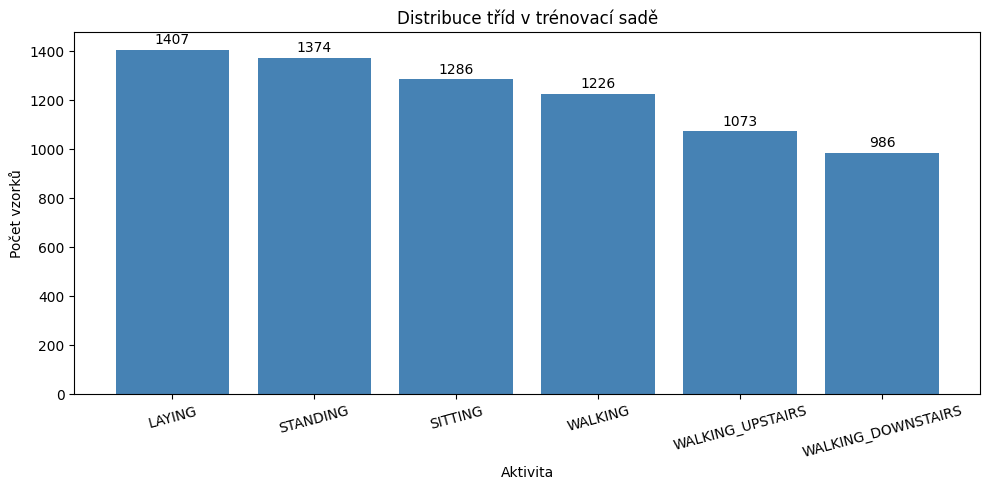

In [ ]:
activity_counts = train['Activity'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(activity_counts.index, activity_counts.values, color='steelblue')
plt.title('Distribuce tříd v trénovací sadě')
plt.xlabel('Aktivita')
plt.ylabel('Počet vzorků')
plt.xticks(rotation=15)

# přidej čísla nad sloupce
for bar, val in zip(bars, activity_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
WINDOW_SECONDS = 2.56

def plot_timeline(subject_id):
    subj_data = train[train['subject'] == subject_id]['Activity'].reset_index(drop=True)

    activity_order = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']
    colors = {'LAYING':'red', 'STANDING':'orange', 'SITTING':'gold',
              'WALKING':'green', 'WALKING_UPSTAIRS':'blue', 'WALKING_DOWNSTAIRS':'purple'}

    activity_num = subj_data.map({a: i for i, a in enumerate(activity_order)})
    color_list = subj_data.map(colors)
    time_minutes = [i * WINDOW_SECONDS / 60 for i in range(len(subj_data))]

    plt.figure(figsize=(14, 4))
    plt.scatter(time_minutes, activity_num, c=color_list, s=5, alpha=0.7)
    plt.yticks(range(len(activity_order)), activity_order)
    plt.xlabel('Čas (minuty)')
    plt.title(f'Sekvence aktivit – subjekt {subject_id}')
    plt.tight_layout()
    plt.show()

interact(plot_timeline,
         subject_id=Dropdown(options=sorted(train['subject'].unique()), description='Subjekt:'))

interactive(children=(Dropdown(description='Subjekt:', options=(np.int64(1), np.int64(3), np.int64(5), np.int6…

<function __main__.plot_timeline(subject_id)>

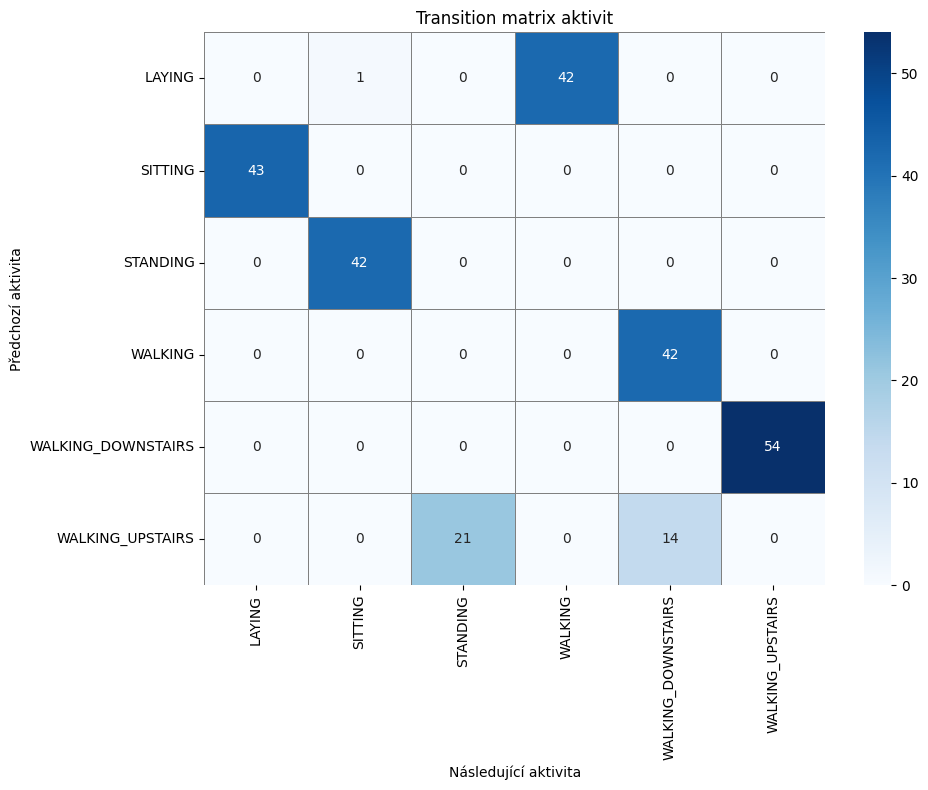

In [ ]:
# Seřaď data podle subjektu (pořadí řádků zachováváme)
train_sorted = train.sort_index()

# Najdi přechody — kde se aktivita změní v rámci stejného subjektu
transitions = []
for subject in train_sorted['subject'].unique():
    subj_data = train_sorted[train_sorted['subject'] == subject]['Activity']
    for i in range(len(subj_data) - 1):
        from_activity = subj_data.iloc[i]
        to_activity = subj_data.iloc[i + 1]
        if from_activity != to_activity:  # jen přechody, ne setrvání ve stejné aktivitě
            transitions.append((from_activity, to_activity))

# Vytvoř transition matrix
trans_df = pd.DataFrame(transitions, columns=['From', 'To'])
trans_matrix = pd.crosstab(trans_df['From'], trans_df['To'])

# Vizualizace
plt.figure(figsize=(10, 8))
sns.heatmap(trans_matrix, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Transition matrix aktivit')
plt.xlabel('Následující aktivita')
plt.ylabel('Předchozí aktivita')
plt.tight_layout()
plt.show()

# Isolation Forest

In [ ]:
X_train = train.drop(columns=['Activity', 'subject'])
y_train = train['Activity']

# Najdi outliery per třída
outlier_mask = np.zeros(len(train), dtype=bool)

for activity in y_train.unique():
    mask = (y_train == activity).values
    X_activity = X_train[mask]

    clf = IsolationForest(contamination=0.05, random_state=42) #contamination je stanovený podíl outlierů
    preds = clf.fit_predict(X_activity)

    outlier_indices = np.where(mask)[0][preds == -1]
    outlier_mask[outlier_indices] = True

print(f"Celkem outlierů: {outlier_mask.sum()}")
print("\nOutliery per třída:")
for activity in y_train.unique():
    mask = (y_train == activity).values
    n_outliers = outlier_mask[mask].sum()
    print(f"  {activity}: {n_outliers}")

Celkem outlierů: 371

Outliery per třída:
  STANDING: 69
  SITTING: 65
  LAYING: 71
  WALKING: 62
  WALKING_DOWNSTAIRS: 50
  WALKING_UPSTAIRS: 54


In [ ]:
# Předpočítej scores pro všechny třídy
scores_per_activity = {}
for activity in y_train.unique():
    X_activity = X_train[y_train == activity]
    clf = IsolationForest(contamination='auto', random_state=42)
    clf.fit(X_activity)
    scores_per_activity[activity] = clf.decision_function(X_activity)

# Interaktivní graf
def plot_scores(activity):
    scores = scores_per_activity[activity]
    n_outliers = (scores < 0).sum()

    plt.figure(figsize=(10, 4))
    plt.hist(scores, bins=50, color='steelblue')
    plt.axvline(x=0, color='red', linestyle='--', label=f'hranice (score=0)')
    plt.title(f'Distribuce anomaly scores – {activity}  ({n_outliers} outlierů)')
    plt.xlabel('Anomaly score')
    plt.ylabel('Počet vzorků')
    plt.legend()
    plt.show()

interact(plot_scores, activity=Dropdown(options=sorted(y_train.unique()), description='Aktivita:'))

interactive(children=(Dropdown(description='Aktivita:', options=('LAYING', 'SITTING', 'STANDING', 'WALKING', '…

<function __main__.plot_scores(activity)>

# T-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


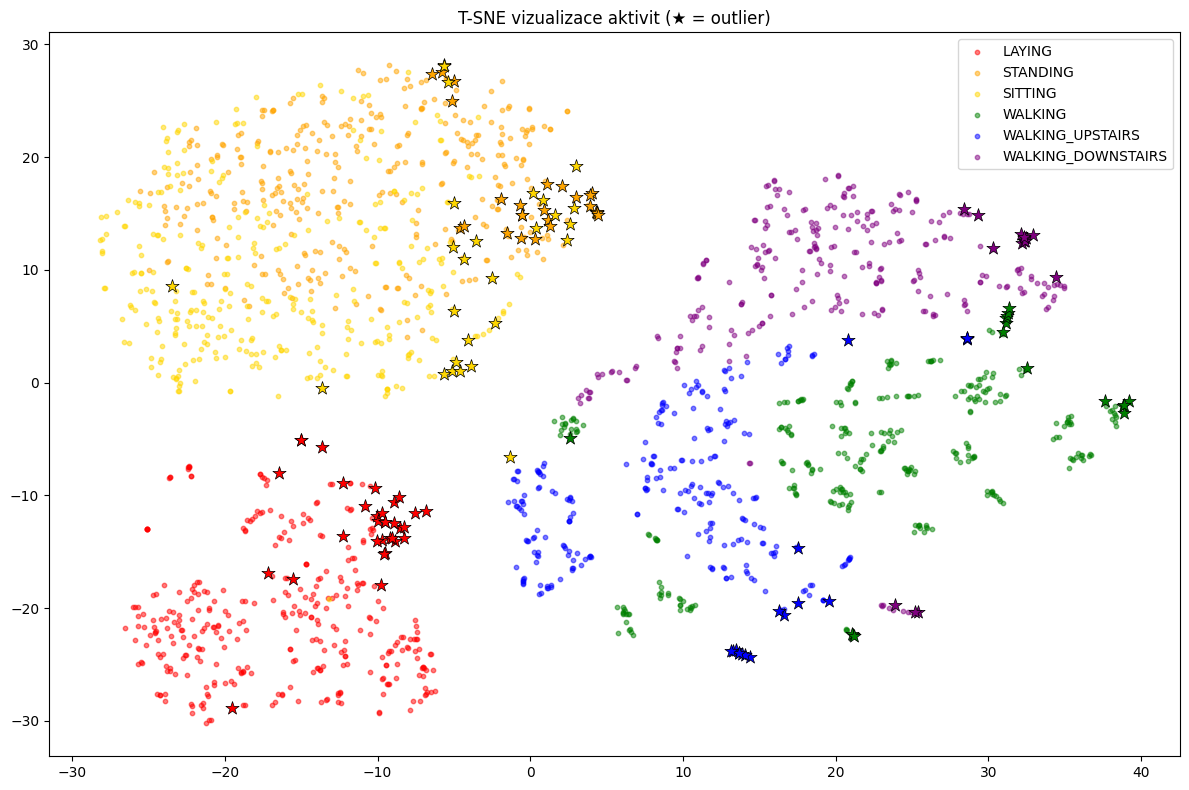

In [ ]:
X_train = train.drop(columns=['Activity', 'subject'])
y_train = train['Activity']

# Podvzorek (stejný jako dřív)
sample_idx = X_train.sample(2000, random_state=42).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Outlier detekce per třída na podvzorku
outlier_mask = np.zeros(len(X_sample), dtype=bool)
for activity in y_sample.unique():
    mask = (y_sample == activity).values
    clf = IsolationForest(contamination='auto', random_state=42)
    clf.fit(X_sample[mask])
    preds = clf.predict(X_sample[mask])
    outlier_mask[mask] = (preds == -1)

# T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
X_embedded = tsne.fit_transform(X_sample)

# Vizualizace
colors = {'LAYING':'red', 'STANDING':'orange', 'SITTING':'gold',
          'WALKING':'green', 'WALKING_UPSTAIRS':'blue', 'WALKING_DOWNSTAIRS':'purple'}

plt.figure(figsize=(12, 8))
for activity, color in colors.items():
    mask = (y_sample == activity).values
    # Normální body
    plt.scatter(X_embedded[mask & ~outlier_mask, 0], X_embedded[mask & ~outlier_mask, 1],
                c=color, label=activity, alpha=0.5, s=10)
    # Outliery jako hvězdičky
    plt.scatter(X_embedded[mask & outlier_mask, 0], X_embedded[mask & outlier_mask, 1],
                c=color, marker='*', s=100, edgecolors='black', linewidths=0.5)

plt.title('T-SNE vizualizace aktivit (★ = outlier)')
plt.legend()
plt.tight_layout()
plt.show()

## XGBoost

Accuracy Score: 0.9913871260199456

Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       422
           SITTING       0.99      0.97      0.98       386
          STANDING       0.97      0.99      0.98       412
           WALKING       1.00      1.00      1.00       368
WALKING_DOWNSTAIRS       1.00      0.99      0.99       296
  WALKING_UPSTAIRS       1.00      1.00      1.00       322

          accuracy                           0.99      2206
         macro avg       0.99      0.99      0.99      2206
      weighted avg       0.99      0.99      0.99      2206



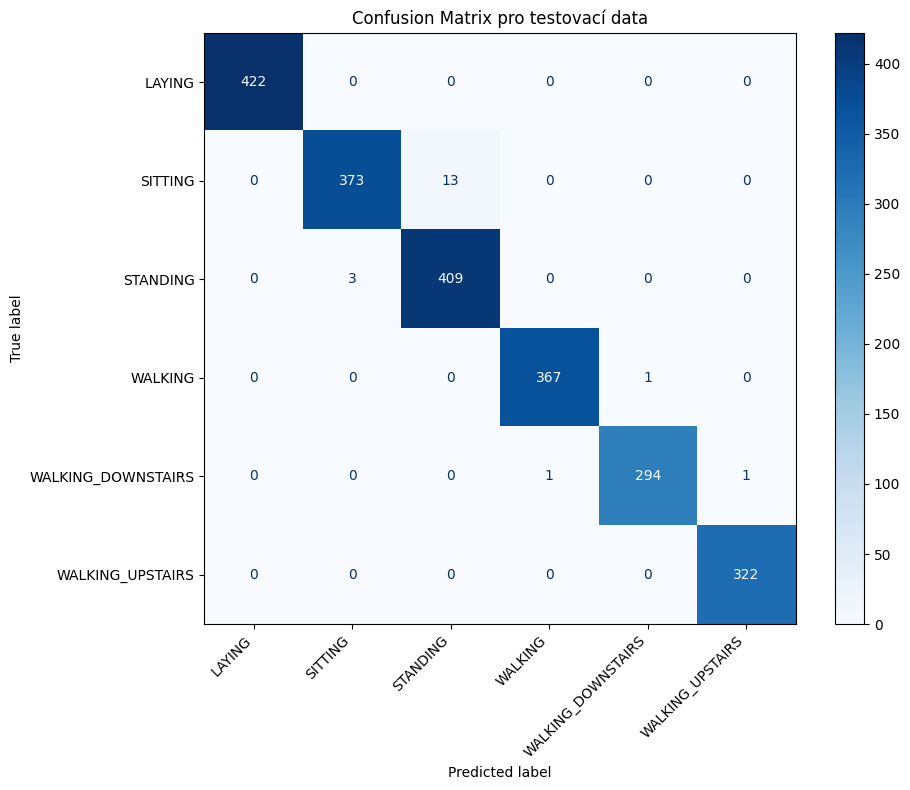

In [16]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Příprava dat
X = train.drop(columns=['Activity', 'subject'])
y = train['Activity']

# Převedení aktivit na číselné hodnoty
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Rozdělení dat na trénovací a validační sady
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Inicializace a trénování XGBoost modelu
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predikce a vyhodnocení
y_pred_xgb = xgb_model.predict(X_test_xgb)

print("Accuracy Score:", accuracy_score(y_test_xgb, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_xgb, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_xgb, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix pro testovací data')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Task
Prepare data (`X`, `y_encoded`) and define an Optuna objective function that performs 3-fold stratified cross-validation to train an XGBoost model, returning the mean validation accuracy.

## Prepare Data and Optuna Objective

### Subtask:
Import necessary libraries, prepare data (`X`, `y_encoded`), and define the Optuna objective function for XGBoost hyperparameter tuning using 3-fold stratified cross-validation.


**Reasoning**:
The subtask requires importing specific libraries and defining an Optuna objective function for hyperparameter tuning. I will create a code block to import `optuna`, `XGBClassifier`, `StratifiedKFold`, and `accuracy_score`, and then define the `objective` function as specified, which includes setting up the hyperparameter search space, performing stratified 3-fold cross-validation, training an XGBoost model for each fold, making predictions, calculating accuracy, and returning the mean accuracy.



In [19]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Prepare data (X and y_encoded are already prepared in a previous cell rxZoO90nYEHR)
# X = train.drop(columns=['Activity', 'subject'])
# le = LabelEncoder()
# y_encoded = le.fit_transform(train['Activity'])

def objective(trial):
    # Hyperparameter search space
    param = {
        'objective': 'multi:softmax',
        'num_class': len(le.classes_),
        'random_state': 42,
        'eval_metric': 'merror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    accuracies = []

    for fold, (train_index, val_index) in enumerate(kf.split(X, y_encoded)):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index]

        model = XGBClassifier(**param)
        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold)
        accuracy = accuracy_score(y_val_fold, y_pred)
        accuracies.append(accuracy)

    return np.mean(accuracies)

print("Optuna objective function 'objective' defined and required libraries imported.")

Optuna objective function 'objective' defined and required libraries imported.


**Reasoning**:
The previous code failed because the `optuna` library was not installed. I need to install `optuna` first before it can be imported and used.



In [20]:
!pip install optuna
print("Optuna installed.")

Optuna installed.


# Task
Re-execute the cell that defines the `objective` function to set up the hyperparameter search space and perform 3-fold stratified cross-validation for XGBoost, returning the mean validation accuracy, and then confirm its successful definition.

## Define Optuna Objective Function

### Subtask:
Re-execute the code in the previous cell to define the `objective` function, which sets up the hyperparameter search space and performs 3-fold stratified cross-validation for XGBoost, returning the mean validation accuracy.
